# Conformal Prediction – Classification Exercises

This notebook walks through conformal prediction for classification, using a CNN trained on a subset of MNIST.

**Contents**
1. Setup & Dataset
2. Model Definition
3. Training
4. Evaluation & Softmax Probabilities
5. Vanilla Split Conformal Classification (SCP)
6. Adaptive Prediction Sets (APS)

## 1. Setup & Dataset

Load 20 % of the MNIST training set and the full test set.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(0)
g = torch.Generator()
g.manual_seed(0)

# ── Load 20 % of MNIST train
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

subset_size  = round(len(train_dataset) * 0.2)
indices      = torch.randperm(len(train_dataset))[:subset_size]
train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, generator=g)
test_loader  = DataLoader(test_dataset, batch_size=1000)

print(f"Train subset size : {subset_size}")
print(f"Test set size     : {len(test_dataset)}")

Train subset size : 12000
Test set size     : 10000


## 2. Model Definition

A lightweight CNN: one convolutional layer followed by two fully-connected layers.

In [4]:
# ── CNN architecture
model = nn.Sequential(
    nn.Conv2d(1, 1, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(4),   # → (1, 7, 7)

    nn.Flatten(),      # → 49
    nn.Linear(1*7*7, 14),
    nn.ReLU(),
    nn.Linear(14, 10)
)
print(model)

Sequential(
  (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=49, out_features=14, bias=True)
  (5): ReLU()
  (6): Linear(in_features=14, out_features=10, bias=True)
)


## 3. Training

Train for one epoch with cross-entropy loss and the Adam optimiser.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── Training loop
epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 359.9151


## 4. Evaluation & Softmax Probabilities

Measure test accuracy and display softmax probability tables for 14 random examples.
The first 4 examples will serve as the **calibration set** and the remaining 10 as the **test set**.

Test accuracy: 0.6498


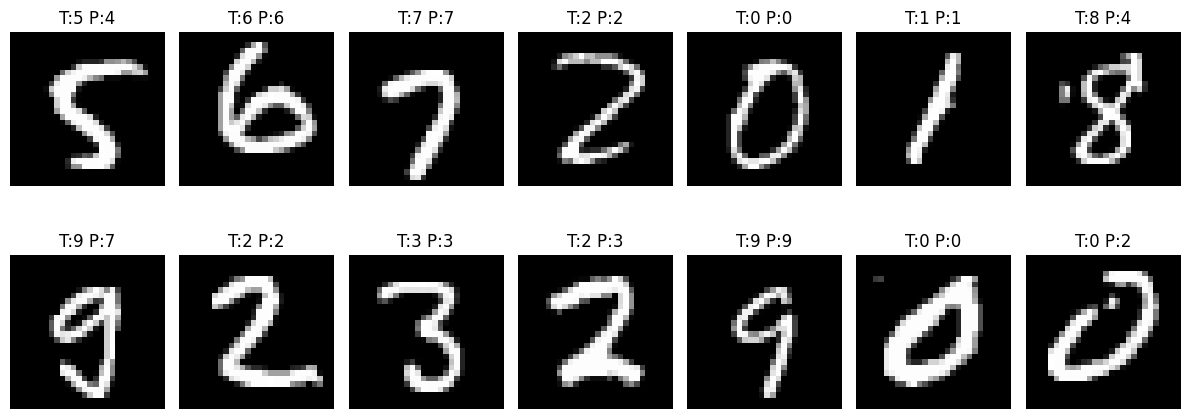

,example,true,pred,0,1,2,3,4,5,6,7,8,9
0,1,5,4,0.021965,0.018469,0.007105,0.009554,0.307872,0.142024,0.023533,0.052182,0.144218,0.273077
1,2,6,6,0.110302,0.005043,0.254471,0.046541,0.012580,0.023330,0.466856,0.006076,0.061394,0.013407
2,3,7,7,0.011172,0.042308,0.004448,0.069019,0.034377,0.030423,0.004614,0.694243,0.037947,0.071449
3,4,2,2,0.065319,0.024005,0.382224,0.377179,0.003590,0.025353,0.041366,0.039281,0.037189,0.004494
4,5,0,0,0.344927,0.002807,0.064756,0.171560,0.028139,0.154874,0.028430,0.072082,0.088952,0.043474
5,6,1,1,0.003058,0.667646,0.069952,0.034560,0.028477,0.018774,0.089211,0.025503,0.037279,0.025541
6,7,8,4,0.034551,0.096469,0.045011,0.060213,0.184426,0.103046,0.066371,0.105557,0.168846,0.135512
7,8,9,7,0.041996,0.020837,0.006046,0.050819,0.149664,0.099536,0.011837,0.316005,0.096101,0.207158
8,9,2,2,0.024795,0.026649,0.509705,0.326463,0.001149,0.010838,0.059584,0.019762,0.019440,0.001615
9,10,3,3,0.032486,0.042370,0.083027,0.552476,0.011248,0.039852,0.022666,0.154514,0.045804,0.015557


In [6]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import pandas as pd

g = torch.Generator()
g.manual_seed(0)

# ── Test accuracy
model.eval()
correct = 0

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Test accuracy: {correct / len(test_loader.dataset):.4f}")

# ── Softmax probabilities for 14 examples
nb = 14
examples, labels = next(iter(DataLoader(test_dataset, batch_size=nb, shuffle=True, generator=g)))

model.eval()
with torch.no_grad():
    outputs = model(examples)
    probs   = F.softmax(outputs, dim=1)
    preds   = probs.argmax(dim=1)

# ── Grid display
fig, axes = plt.subplots(2, 7, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(examples[i].squeeze(), cmap="gray")
    ax.set_title(f"T:{labels[i].item()} P:{preds[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# ── Build probability DataFrame
rows = []
for i in range(nb):
    row = {"example": i + 1, "true": labels[i].item(), "pred": preds[i].item()}
    for c in range(10):
        row[str(c)] = probs[i, c].item()
    rows.append(row)

df = pd.DataFrame(rows)
df

## 5. Vanilla Split Conformal Classification (SCP)

Use the **first 4 rows** of `df` as the calibration set and the last 10 as the test set.

The conformity score for each calibration example is the softmax probability assigned to its **true** class. The threshold `q` is the `α`-quantile of the sorted calibration scores.

**α = 0.25** → 75 % marginal coverage guarantee.

In [7]:
import numpy as np

alpha    = 0.25
test_idx = len(df) - 10   # 4 calibration, 10 test

# ── Calibration conformity scores: p(true class)
res_cal = [1]   # sentinel ∞ score
for i in range(len(df)-test_idx):
    true_col = int(df.iloc[i, 1]) + 3   # column offset: example, true, pred, then class cols
    res_cal.append(df.iloc[i, true_col])

sort_res = np.sort(res_cal)
q_index  = int(np.floor(alpha * (len(df) - test_idx + 1)))
q        = sort_res[q_index - 1]

print("Sorted calibration scores:", sort_res)
print("Quantile index           :", q_index)
print("Threshold q              :", q)

Sorted calibration scores: [0.14202377 0.16884583 0.20715772 0.3449266  0.38222387 0.46685618
 0.50970507 0.55247551 0.66764617 0.69424295 1.        ]
Quantile index           : 2
Threshold q              : 0.16884583234786987


In [8]:
# ── Prediction sets for each test example
# Include class c if its softmax probability ≥ q
test_set = [[] for _ in range(test_idx)]

for i in range(10, len(df)):
    for j in range(3, 13):
        R_i = df.iloc[i, j]
        col_name = df.columns[j]

        if R_i >= q:
            test_set[i - 10].append(col_name)

print("Prediction sets:")
for i, s in enumerate(test_set):
    true_label = df.iloc[10 + i, 1]
    print(f"  Example {10 + i + 1} (true={true_label}): {s}")

Prediction sets:
  Example 11 (true=2): ['2', '3']
  Example 12 (true=9): ['4', '9']
  Example 13 (true=0): ['0']
  Example 14 (true=0): ['0', '2']


## 6. Adaptive Prediction Sets (APS)

APS builds sets by sorting classes in **descending probability order** and accumulating until the cumulative probability exceeds the threshold `q`.

The calibration score for example `i` is the **sum of probabilities** down to and including the true class in the sorted order.

In [9]:
# ── Calibration: cumulative probability up to the true class
cal_set_sorted = [df.iloc[i, 3:13].sort_values(ascending=False) for i in range(10)]

res_cal = []
for i in range(10):
    s          = cal_set_sorted[i]
    true_label = str(df.iloc[i, 1])
    idx        = list(s.index).index(true_label)
    res_cal.append(s.iloc[:idx + 1].sum())

sort_res = np.sort(res_cal)
q_index = int(np.ceil((1 - alpha) * (len(df) - test_idx + 1)))
q       = sort_res[q_index - 1]

print("Sorted APS calibration scores:", sort_res)
print("Quantile index               :", q_index)
print("Threshold q                  :", q)

Sorted APS calibration scores: [0.3449266  0.35327184 0.38222387 0.46685618 0.50970507 0.52316295
 0.55247551 0.66764617 0.69424295 0.867191  ]
Quantile index               : 9
Threshold q                  : 0.6942429542541504


In [10]:
# ── APS prediction sets for each test example
test_set = [[] for _ in range(test_idx)]

for i in range(10, len(df)):
    row = df.iloc[i, 3:13]
    row_sorted = row.sort_values(ascending=False)

    classes = list(row_sorted.index)
    probs = list(row_sorted.values)

    cum_probs = []
    s = 0
    for p in probs:
        s += p
        cum_probs.append(s)

    t = 0
    while t < len(cum_probs) and cum_probs[t] < q:
        t += 1

    test_set[i - 10] = classes[:t+1]
    


print("APS prediction sets:")
for i, s in enumerate(test_set):
    true_label = df.iloc[10 + i, 1]
    print(f"  Example {10 + i + 1} (true={true_label}): {s}")

APS prediction sets:
  Example 11 (true=2): ['3', '2']
  Example 12 (true=9): ['9', '4', '7']
  Example 13 (true=0): ['0', '2', '5', '8']
  Example 14 (true=0): ['2', '0', '6']
